***Proyecto Final***
<br>
**Laboratorio Computacional de Analitica**
<br>
*Juan Pablo Villarraga Poveda*

**Contexto**
<br>
<br>
El ICFES es el Instituto Colombiano para el Fomento de la Educación Superior y está adscrito al Ministerio de Educación a nivel nacional. Como parte de sus funciones, el ICFES administra las pruebas Saber 11, las cuales evalúan a todos los estudiantes del país al final de su educación secundaria. El examen contiene preguntas que evalúan una variedad de áreas del conocimiento (ej., matemáticas, física, inglés, etc.) y se lleva a cabo dos veces al año, ajustándose a los diferentes calendarios académicos que siguen las instituciones educativas. Al momento de inscribirse a las pruebas, los estudiantes diligencian un formulario que recoge información sociodemográfica y relacionada con la institución a la que pertenecen. El fin es obtener información con respecto al desempeño de los estudiantes en la prueba y de sus características.
<br>
<br>
Para este caso, se tomó la base de datos de reulstados de las pruebvas Saber 11 entre los años 2010 al 2022 de la ciudad de Cali, Colombia. Esta base de datos trae caracteristicas propias de la institución, puntajes en las áreas de evaluación, y caracteristicas socioeconómicas de los estudiantes.


**Fase 1: obtener e inspeccionar archivos**

In [118]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd 
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
from pygam import LinearGAM, s, f, l
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn import metrics
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LassoCV
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestRegressor
import numpy as np



In [71]:
# CARGA DE BASE DE DATOS
df = pd.read_csv("Cali_historico_saber11_13022024_20260307.zip", sep=",")


In [72]:
# ESTADISTICAS POR PUNTAJE
print("=== Estadísticas descriptivas de Puntajes por Área de Estudio 2010 - 2022 ===")
punt_cols = df.filter(like="PUNT_")
display(punt_cols.describe())

num_registros = len(df)
print("Número de registros:", num_registros)

=== Estadísticas descriptivas de Puntajes por Área de Estudio 2010 - 2022 ===


,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
count,346977.000000,347028.000000,196295.000000,196295.000000,196295.000000,196295.000000
mean,50.547680,50.138252,50.853705,51.686243,54.178486,261.180687
std,13.351645,12.073257,11.937698,10.998659,10.317050,51.513134
min,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,42.000000,42.000000,44.000000,47.000000,223.000000
50%,48.000000,49.430000,51.000000,51.000000,54.000000,258.000000
75%,57.000000,58.000000,59.000000,59.000000,61.000000,296.000000
max,116.950000,127.000000,100.000000,100.000000,100.000000,495.000000


Número de registros: 347028


In [73]:

# Visualizar NANs por Año y Area de Conocimiento
df["AÑO"] = df["PERIODO"].astype(str).str[:4].astype(int)

punt_cols = df.filter(like="PUNT_").copy()
punt_cols["AÑO"] = df["AÑO"]

resumen_media = punt_cols.groupby("AÑO").mean()
display(resumen_media)



,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
AÑO,,,,,,
2010,49.914076,50.178724,NaN,NaN,NaN,NaN
2011,44.658457,47.569632,NaN,NaN,NaN,NaN
2012,44.911480,45.808336,NaN,NaN,NaN,NaN
2013,47.753459,46.927965,NaN,NaN,NaN,NaN
2014,50.507572,49.739742,50.009765,49.049517,50.542404,248.113854
2015,51.926003,50.884624,51.387544,51.451975,51.542301,256.817888
2016,54.569185,52.594693,52.330668,54.050894,53.962352,266.694718
2017,52.154300,51.267708,51.865367,52.756633,54.864061,263.234313
2018,63.070686,58.942330,58.086957,58.812347,61.041218,297.599566


In [74]:
# IMPORTANTE: Se eliminan aquellos resultados de estudiantes entre 2010 y 2013, esto debiod al alto numero de valores ausentes que representa para el proyecto.

años_a_eliminar = [2010, 2011, 2012, 2013]
df = df[~df["AÑO"].isin(años_a_eliminar)]


In [83]:
# Visualizar NANs por Año y Area de Conocimiento
punt_cols = df.filter(like="PUNT_").copy()
punt_cols["AÑO"] = df["AÑO"]

resumen_media = punt_cols.groupby("AÑO").mean()
display(resumen_media)

,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
AÑO,,,,,,
2014,50.507572,49.739742,50.009765,49.049517,50.542404,248.113854
2015,51.926003,50.884624,51.387544,51.451975,51.542301,256.817888
2016,54.569185,52.594693,52.330668,54.050894,53.962352,266.694718
2017,52.154300,51.267708,51.865367,52.756633,54.864061,263.234313
2018,63.070686,58.942330,58.086957,58.812347,61.041218,297.599566
2019,50.884376,51.066223,47.826528,49.482279,53.649415,252.679492
2020,64.271273,58.913617,55.423849,56.692247,59.956513,291.213302
2021,64.716486,59.355954,56.606731,56.670020,60.462411,293.822938
2022,52.125051,51.083742,49.145086,50.038564,54.513485,256.332746


In [ ]:
#Años

print("=== Años disponibles en el dataset ===")
lista_años = sorted(df["AÑO"].unique())
print(lista_años)

#Control de NAs

print("=== Control de NaNs ===")

nan_counts = df.isna().sum()
nan_percent = ((nan_counts / len(df)) * 100).round(2).astype(str) + '%'
nan_info = pd.DataFrame({
    "NaN_count": nan_counts,
    "NaN_percent": nan_percent
})
nan_info = nan_info[nan_info["NaN_count"] > 0].sort_values(by="NaN_count", ascending=False)

print(nan_info)


=== Años disponibles en el dataset ===
['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022']
=== Control de NaNs ===
                          NaN_count NaN_percent
COLE_BILINGUE                 22508      11.09%
FAMI_ESTRATOVIVIENDA           9249       4.56%
FAMI_TIENEINTERNET             8857       4.36%
FAMI_EDUCACIONPADRE            8737       4.31%
FAMI_EDUCACIONMADRE            8681       4.28%
PUNT_LECTURA_CRITICA           6633       3.27%
PUNT_C_NATURALES               6633       3.27%
PUNT_SOCIALES_CIUDADANAS       6633       3.27%
PUNT_GLOBAL                    6633       3.27%
FAMI_TIENEAUTOMOVIL            6177       3.04%
FAMI_PERSONASHOGAR             5947       2.93%
FAMI_CUARTOSHOGAR              5941       2.93%
FAMI_TIENECOMPUTADOR           5861       2.89%
FAMI_TIENELAVADORA             5821       2.87%
COLE_CARACTER                  4880        2.4%
ESTU_MCPIO_RESIDE               213        0.1%
ESTU_DEPTO_RESIDE               213        0.1%


In [77]:
print("=== Estadísticas descriptivas de Puntajes por Área de Estudio 2014 - 2022 ===")
punt_cols1 = df.filter(like="PUNT_")
display(punt_cols1.describe())
num_registros = len(df)
print("Número de registros:", num_registros)

=== Estadísticas descriptivas de Puntajes por Área de Estudio 2014 - 2022 ===


,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
count,202877.000000,202928.000000,196295.000000,196295.000000,196295.000000,196295.000000
mean,53.169600,51.927551,50.853705,51.686243,54.178486,261.180687
std,13.502309,12.123181,11.937698,10.998659,10.317050,51.513134
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,44.000000,44.000000,42.000000,44.000000,47.000000,223.000000
50%,51.000000,52.000000,51.000000,51.000000,54.000000,258.000000
75%,61.000000,60.000000,59.000000,59.000000,61.000000,296.000000
max,100.000000,109.000000,100.000000,100.000000,100.000000,495.000000


Número de registros: 202928


*Resultados*
<br>
<br>
Como se puede obsevar en la de estadisticas descriptivas de las varibales de interes, que supone los puntajes en cada area de evaluacion, tenemos lo siguientes:
<br>
* Tenemos un menor grado de datos en las areas de Sociales $ Ciudadanas, Ciencias Naturales, Lectura Critica y en el Puntaje Global. Esto se explica a que la prueba Saber 11 no evaluaba estas areas de conocimiento entre los años 2010 y 2013, fue en 2014 que tuvo en cuentas estos rubros evaluativos.
<br>
<br>
* Como solución a lo anterior, se toma la decision de eliminar los resultados en las pruebas de cada estudiante entre los años 2010 a 2013, con el fin de no distorsionar los resultados de las estadisticas y modelos posteriores. Dejando asi la base con 202.928 registros, frente a los 347.028 antes de ser eliminados los registros.
<br>
<br>
* En promedio, lospuntajes de ingles y lectura critica son ligeramente mayores a las demás áreas de conocimiento. El área con menor promedio con respectoa  las demás es Ciencias Sociales y Ciudadanas.

**Fase 2: identificar características y relaciones en las variables**

In [85]:
# ESTADISTICAS POR TIPO DE AREA DONDE SE ENCUENTRA LA INSTITUCION EDUCATIVA

df_grouped = df.groupby(["AÑO", "COLE_AREA_UBICACION"])["PUNT_GLOBAL"].mean().reset_index()

fig = px.bar(
    df_grouped,
    x="AÑO",
    y="PUNT_GLOBAL",
    color="COLE_AREA_UBICACION",
    barmode="group",
    title="Promedio de PUNT_GLOBAL por año y área"
)

df_line = df_grouped.groupby("AÑO")["PUNT_GLOBAL"].mean().reset_index()

fig.add_scatter(
    x=df_line["AÑO"],
    y=df_line["PUNT_GLOBAL"],
    mode="lines+markers",
    name="Tendencia general",
    line=dict(color="black", dash="dash")
)

fig.update_layout(
    xaxis_title="Año",
    yaxis_title="Promedio Puntaje Global",
    legend_title="Área de ubicación"
)

fig.show()


In [ ]:


punt_cols = [
    "PUNT_INGLES",
    "PUNT_MATEMATICAS",
    "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_C_NATURALES",
    "PUNT_LECTURA_CRITICA"
]

df_long = df.melt(
    id_vars=["COLE_CARACTER"], 
    value_vars=punt_cols,
    var_name="Asignatura",
    value_name="Puntaje"
)

def plot_caracter(caracter):
    df_filtrado = df_long[df_long["COLE_CARACTER"] == caracter]
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=df_filtrado,
        x="Asignatura",
        y="Puntaje",
        ci=None
    )
    plt.title(f"Distribución de puntajes por asignatura - {caracter}")
    plt.xlabel("Asignatura")
    plt.ylabel("Puntaje promedio")
    plt.xticks(rotation=30)
    plt.show()

dropdown = widgets.Dropdown(
    options=df["COLE_CARACTER"].unique(),
    description="Carácter:"
)

widgets.interactive(plot_caracter, caracter=dropdown)


interactive(children=(Dropdown(description='Carácter:', options=('TÉCNICO/ACADÉMICO', 'ACADÉMICO', 'TÉCNICO', …

TraitError: Invalid selection: value not found

In [ ]:
punt_cols = [
    "PUNT_INGLES",
    "PUNT_MATEMATICAS",
    "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_C_NATURALES",
    "PUNT_LECTURA_CRITICA"
]

df_long = df.melt(
    id_vars=["COLE_JORNADA"], 
    value_vars=punt_cols,
    var_name="Asignatura",
    value_name="Puntaje"
)

def plot_caracter(caracter):
    df_filtrado = df_long[df_long["COLE_JORNADA"] == caracter]
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=df_filtrado,
        x="Asignatura",
        y="Puntaje",
        ci=None
    )
    plt.title(f"Distribución de puntajes por asignatura - {caracter}")
    plt.xlabel("Asignatura")
    plt.ylabel("Puntaje promedio")
    plt.xticks(rotation=30)
    plt.show()

dropdown = widgets.Dropdown(
    options=df["COLE_JORNADA"].unique(),
    description="Jornada:"
)

widgets.interactive(plot_caracter, caracter=dropdown)

interactive(children=(Dropdown(description='Jornada:', options=('MAÑANA', 'COMPLETA', 'TARDE', 'NOCHE', 'SABAT…

In [ ]:
punt_cols = [
    "PUNT_INGLES",
    "PUNT_MATEMATICAS",
    "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_C_NATURALES",
    "PUNT_LECTURA_CRITICA"
]

df_long = df.melt(
    id_vars=["COLE_NATURALEZA"], 
    value_vars=punt_cols,
    var_name="Asignatura",
    value_name="Puntaje"
)

def plot_caracter(caracter):
    df_filtrado = df_long[df_long["COLE_NATURALEZA"] == caracter]
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=df_filtrado,
        x="Asignatura",
        y="Puntaje",
        ci=None
    )
    plt.title(f"Distribución de puntajes por asignatura - {caracter}")
    plt.xlabel("Asignatura")
    plt.ylabel("Puntaje promedio")
    plt.xticks(rotation=30)
    plt.show()

dropdown = widgets.Dropdown(
    options=df["COLE_NATURALEZA"].unique(),
    description="Naturaleza:"
)

widgets.interactive(plot_caracter, caracter=dropdown)

interactive(children=(Dropdown(description='Naturaleza:', options=('OFICIAL', 'NO OFICIAL'), value='OFICIAL'),…

In [61]:
punt_cols = [
    "PUNT_INGLES",
    "PUNT_MATEMATICAS",
    "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_C_NATURALES",
    "PUNT_LECTURA_CRITICA"
]

df_long = df.melt(
    id_vars=["FAMI_EDUCACIONMADRE"], 
    value_vars=punt_cols,
    var_name="Asignatura",
    value_name="Puntaje"
)

def plot_caracter(caracter):
    df_filtrado = df_long[df_long["FAMI_EDUCACIONMADRE"] == caracter]
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=df_filtrado,
        x="Asignatura",
        y="Puntaje",
        ci=None
    )
    plt.title(f"Distribución de puntajes por asignatura - {caracter}")
    plt.xlabel("Asignatura")
    plt.ylabel("Puntaje promedio")
    plt.xticks(rotation=30)
    plt.show()

dropdown = widgets.Dropdown(
    options=df["FAMI_EDUCACIONMADRE"].unique(),
    description="Educación Madre:"
)

widgets.interactive(plot_caracter, caracter=dropdown)

interactive(children=(Dropdown(description='Educación Madre:', options=('Secundaria (Bachillerato) incompleta'…

In [62]:
punt_cols = [
    "PUNT_INGLES",
    "PUNT_MATEMATICAS",
    "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_C_NATURALES",
    "PUNT_LECTURA_CRITICA"
]

df_long = df.melt(
    id_vars=["FAMI_EDUCACIONPADRE"], 
    value_vars=punt_cols,
    var_name="Asignatura",
    value_name="Puntaje"
)

def plot_caracter(caracter):
    df_filtrado = df_long[df_long["FAMI_EDUCACIONPADRE"] == caracter]
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=df_filtrado,
        x="Asignatura",
        y="Puntaje",
        ci=None
    )
    plt.title(f"Distribución de puntajes por asignatura - {caracter}")
    plt.xlabel("Asignatura")
    plt.ylabel("Puntaje promedio")
    plt.xticks(rotation=30)
    plt.show()

dropdown = widgets.Dropdown(
    options=df["FAMI_EDUCACIONPADRE"].unique(),
    description="Educación Padre:"
)

widgets.interactive(plot_caracter, caracter=dropdown)

interactive(children=(Dropdown(description='Educación Padre:', options=('Secundaria (Bachillerato) completa', …

In [63]:

# Variables de interés
fami_cols = [
    "FAMI_TIENEAUTOMOVIL",
    "FAMI_TIENECOMPUTADOR",
    "FAMI_TIENEINTERNET",
    "FAMI_TIENELAVADORA"
]

def plot_estrato(estrato):
    df_filtrado = df[df["FAMI_ESTRATOVIVIENDA"] == estrato]
    
    df_long = df_filtrado.melt(
        id_vars=["FAMI_ESTRATOVIVIENDA"],
        value_vars=fami_cols,
        var_name="Bien",
        value_name="Respuesta"
    )
    
    conteo = df_long.groupby(["Bien", "Respuesta"]).size().reset_index(name="Conteo")
    
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=conteo,
        x="Bien",
        y="Conteo",
        hue="Respuesta",
        ci=None
    )
    plt.title(f"Conteo de bienes familiares por estrato {estrato}")
    plt.xlabel("Bien")
    plt.ylabel("Número de respuestas")
    plt.xticks(rotation=30)
    plt.legend(title="Respuesta")
    plt.show()

dropdown = widgets.Dropdown(
    options=df["FAMI_ESTRATOVIVIENDA"].unique(),
    description="Estrato:"
)

widgets.interactive(plot_estrato, estrato=dropdown)


interactive(children=(Dropdown(description='Estrato:', options=('Estrato 5', 'Estrato 3', 'Estrato 4', 'Estrat…

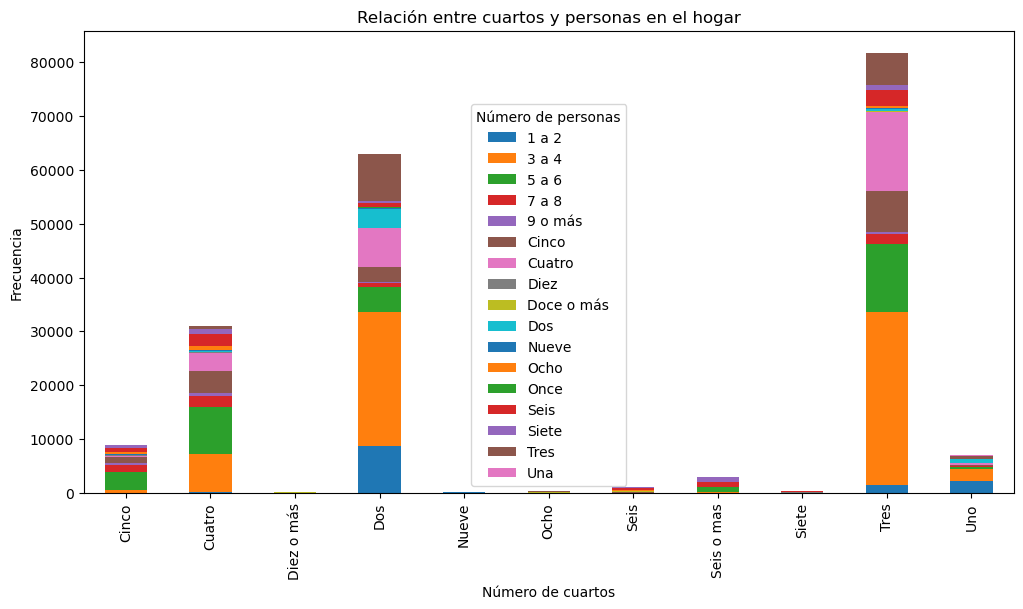

In [64]:
import pandas as pd

# Tabla cruzada
tabla = pd.crosstab(df["FAMI_CUARTOSHOGAR"], df["FAMI_PERSONASHOGAR"])

# Gráfico de barras apiladas
tabla.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Relación entre cuartos y personas en el hogar")
plt.xlabel("Número de cuartos")
plt.ylabel("Frecuencia")
plt.legend(title="Número de personas")
plt.show()



*Resultados*
<br>
<br>
Como se puede obsevar, se pueden obtener los siguientes comnetarios dadas las evaluaciones correspondientes:
<br>
* Se puede observar que, de forma general durante toda la serie de tiempo los resulatos de instituciones de áreas URBANAS son mejores que en áreas RURALES. Sin embargo, si se habla de un mejor rendimiento académico con el pasar de los años, la tendencia no es clara (negativa o positiva).
<br>
<br>
* Asimismo, se puede observar que para para la naturaleza del tipo de eduacion que presta la institucion, las que son ACADEMICAS, presnetan un mejor resultadfo en Ingles con respecto a las demás áreas de evaluación. Pero para los demás tipos de eduación (TECNICO, TECNICO/ACADEMICO, NO APLICA), presnetan un mejor rendimiento en el área de Lectura Critica.
<br>
<br>
* Esto mismo sucede con el tipo de jornada de la institución, se puede observar que para la jornada que presta la institucion, las que son COMPLETA, presnetan un mejor resultadfo en Ingles con respecto a las demás áreas de evaluación. Pero para los demás tipos de jornada (MAÑANA, NOCTURNA, SABATINA, UNICA), presnetan un mejor rendimiento en el área de Lectura Critica.
<br>
<br>
* Caso similar con el tipo de jurisdiccion de la institución, se puede observar que las instituciones que son NO OFICIAL (Privados), presnetan un mejor resultadfo en Ingles con respecto a las demás áreas de evaluación. Pero para las que son OFICIAL (Publico), presnetan un mejor rendimiento en el área de Lectura Critica.
<br>
<br>
* Por otro lado, si vemos la relacion entre número de habitaciones por hogar del estudiante y el numero de persona con las que vive (relacion de ascinamiento), la mayoria de los hogares cuenta dos o tres habitaciones en el hogar, y estos cuantan con una concentraciuón de 3 a 4 personas en el hogar.
<br>
<br>
* Por ultimo, se puede ver que indepdendiente el nivel de estrato socioeconomica del hogar en el que vive el estudiante, la mayoria cuentan con los servicios de internet, internet y lavadora. Caso contario sucede con que el estudiante o en el hogar del estudiante cuente con automovil, ya que en los Estratos 1,2 y 3 predomina el no contar con automovil.




**Fase 3: abordar relación variables-desempeño a través de un modelo**

In [96]:

# TRATAMIENTO Y TRANFORMACION DE VARIABLES CATEGORICAS

df["FAMI_TIENEAUTOMOVIL"] = df["FAMI_TIENEAUTOMOVIL"].map({"Si": 1, "No": 0})
df["FAMI_TIENECOMPUTADOR"] = df["FAMI_TIENECOMPUTADOR"].map({"Si": 1, "No": 0})
df["FAMI_TIENEINTERNET"] = df["FAMI_TIENEINTERNET"].map({"Si": 1, "No": 0})
df["FAMI_TIENELAVADORA"] = df["FAMI_TIENELAVADORA"].map({"Si": 1, "No": 0})
df["COLE_NATURALEZA"] = df["COLE_NATURALEZA"].map({"OFICIAL": 1, "NO OFICIAL": 0})
df["COLE_BILINGUE"] = df["COLE_BILINGUE"].map({"S": 1, "N": 0})
df["COLE_AREA_UBICACION"] = df["COLE_AREA_UBICACION"].map({"URBANA": 1, "RURAL": 0})
df["ESTU_GENERO"] = df["ESTU_GENERO"].map({"F": 1, "M": 0})
df["ESTU_PRIVADO_LIBERTAD"] = df["ESTU_PRIVADO_LIBERTAD"].map({"S": 1, "N": 0})

jornada_map = {
    "COMPLETA": 0,
    "MAÑANA": 1,
    "TARDE": 2,
    "NOCHE": 3,
    "SABATINA": 4,
    "UNICA": 5
}

df["COLE_JORNADA_NUM"] = df["COLE_JORNADA"].map(jornada_map)

GENERO_MAP = {
    "MIXTO": 0,
    "MASCULINO": 1,
    "FEMENINO": 2
}

df["COLE_GENERO_NUM"] = df["COLE_GENERO"].map(GENERO_MAP)

CALENDARIO_MAP = {
    "A": 0,
    "B": 1,
    "OTRO": 2
}

df["COLE_CALENDARIO_NUM"] = df["COLE_CALENDARIO"].map(CALENDARIO_MAP)

caracter_map = {
    "ACADÉMICO": 0,
    "TÉCNICO/ACADÉMICO": 1,
    "TÉCNICO": 2,
    "NO APLICA": 3
}

df["COLE_CARACTER_NUM"] = df["COLE_CARACTER"].map(caracter_map)

cuartos_map = {
    "Uno": 0,
    "Dos": 1,
    "Tres": 2,
    "Cuatro": 3,
    "Cinco": 4,
    "Seis": 5,
    "Siete": 6,
    "Ocho": 7,
    "Nueve": 8,
    "Diez o más": 9,
    "Seis o mas": 10 
}

df["FAMI_CUARTOSHOGAR_NUM"] = df["FAMI_CUARTOSHOGAR"].map(cuartos_map)


educacion_mama_map = {
    "Ninguno": 0,
    "No sabe": 1,
    "No Aplica": 2,
    "Primaria incompleta": 3,
    "Primaria completa": 4,
    "Secundaria (Bachillerato)": 5,
    "Técnica o tecnológica": 6,
    "Educación profesional": 7,
    "Postgrado": 8
}

df["FAMI_EDUCACIONMADRE_NUM"] = df["FAMI_EDUCACIONMADRE"].map(educacion_mama_map)

educacion_padre_map = {
    "Ninguno": 0,
    "No sabe": 1,
    "No Aplica": 2,
    "Primaria incompleta": 3,
    "Primaria completa": 4,
    "Secundaria (Bachillerato)": 5,
    "Técnica o tecnológica": 6,
    "Educación profesional": 7,
    "Postgrado": 8
}


df["FAMI_EDUCACIONPADRE_NUM"] = df["FAMI_EDUCACIONPADRE"].map(educacion_padre_map)

estrato_map = {
    "Estrato 1": 0,
    "Estrato 2": 1,
    "Estrato 3": 2,
    "Estrato 4": 3,
    "Estrato 5": 4,
    "Estrato 6": 5,
    "Sin Estrato": 6
}


df["FAMI_ESTRATOVIVIENDA_NUM"] = df["FAMI_ESTRATOVIVIENDA"].map(estrato_map)

personas_map = {
    "Una": 0,
    "Dos": 1,
    "Tres": 2,
    "Cuatro": 3,
    "Cinco": 4,
    "Seis": 5,
    "Siete": 6,
    "Ocho": 7,
    "Nueve": 8,
    "Diez": 9,
    "Once": 10,
    "Doce o más": 11,
    "1 a 2": 12,
    "3 a 4": 13,
    "5 a 6": 14,
    "7 a 8": 15,
    "9 o más": 16
}

df["FAMI_PERSONASHOGAR_NUM"] = df["FAMI_PERSONASHOGAR"].map(personas_map)


In [110]:

df = df.dropna(subset=["PUNT_INGLES"])
df = df.dropna(subset=["PUNT_MATEMATICAS"])
df = df.dropna(subset=["PUNT_SOCIALES_CIUDADANAS"])
df = df.dropna(subset=["PUNT_C_NATURALES"])
df = df.dropna(subset=["PUNT_LECTURA_CRITICA"])

X = df[[
    "FAMI_TIENEAUTOMOVIL", "FAMI_TIENECOMPUTADOR", "FAMI_TIENEINTERNET",
    "FAMI_TIENELAVADORA", "COLE_NATURALEZA", "COLE_BILINGUE",
    "COLE_AREA_UBICACION", "ESTU_GENERO", "ESTU_PRIVADO_LIBERTAD",
    "COLE_JORNADA_NUM", "COLE_GENERO_NUM", "COLE_CALENDARIO_NUM",
    "COLE_CARACTER_NUM", "FAMI_CUARTOSHOGAR_NUM", "FAMI_EDUCACIONMADRE_NUM",
    "FAMI_EDUCACIONPADRE_NUM", "FAMI_ESTRATOVIVIENDA_NUM", "FAMI_PERSONASHOGAR_NUM"
]]


In [120]:


y = df["PUNT_INGLES"]

XTrain, XTest, yTrain, yTest = train_test_split(X, y, test_size=0.33, random_state=0)

rf_INGLES_model = RandomForestRegressor(n_estimators=500, random_state=42)
rf_INGLES_model.fit(XTrain, yTrain)

y_pred = rf_INGLES_model.predict(XTest)

mse_INGLES = mean_squared_error(yTest, y_pred)
r2_INGLES = r2_score(yTest, y_pred)

print(f"MSE del modelo: {mse_INGLES:.2f}")
print(f"R² del modelo: {r2_INGLES:.4f}")

##----------------------------------------------------------------------------------##

y = df["PUNT_MATEMATICAS"]

XTrain1, XTest1, yTrain1, yTest1 = train_test_split(X, y, test_size=0.33, random_state=0)

rf_MATEMATICAS_model = RandomForestRegressor(n_estimators=500, random_state=42)
rf_MATEMATICAS_model.fit(XTrain1, yTrain1)

y_pred1 = rf_MATEMATICAS_model.predict(XTest1)

mse_MATEMATICAS = mean_squared_error(yTest1, y_pred1)
r2_MATEMATICAS = r2_score(yTest1, y_pred1)

print(f"MSE del modelo: {mse_MATEMATICAS:.2f}")
print(f"R² del modelo: {r2_MATEMATICAS:.4f}")

##----------------------------------------------------------------------------------##

y = df["PUNT_SOCIALES_CIUDADANAS"]

XTrain2, XTest2, yTrain2, yTest2 = train_test_split(X, y, test_size=0.33, random_state=0)

rf_SOCIALES_CIUDADANAS_model = RandomForestRegressor(n_estimators=500, random_state=42)
rf_SOCIALES_CIUDADANAS_model.fit(XTrain2, yTrain2)

y_pred2 = rf_SOCIALES_CIUDADANAS_model.predict(XTest2)

mse_SOCIALES_CIUDADANAS = mean_squared_error(yTest2, y_pred2)
r2_SOCIALES_CIUDADANAS = r2_score(yTest2, y_pred2)

print(f"MSE del modelo: {mse_SOCIALES_CIUDADANAS:.2f}")
print(f"R² del modelo: {r2_SOCIALES_CIUDADANAS:.4f}")

##----------------------------------------------------------------------------------##

y = df["PUNT_C_NATURALES"]

XTrain3, XTest3, yTrain3, yTest3 = train_test_split(X, y, test_size=0.33, random_state=0)

rf_C_NATURALES_model = RandomForestRegressor(n_estimators=500, random_state=42)
rf_C_NATURALES_model.fit(XTrain3, yTrain3)

y_pred3 = rf_C_NATURALES_model.predict(XTest3)

mse_C_NATURALES = mean_squared_error(yTest3, y_pred3)
r2_C_NATURALES = r2_score(yTest3, y_pred3)

print(f"MSE del modelo: {mse_C_NATURALES:.2f}")
print(f"R² del modelo: {r2_C_NATURALES:.4f}")

##----------------------------------------------------------------------------------##

y = df["PUNT_LECTURA_CRITICA"]

XTrain4, XTest4, yTrain4, yTest4 = train_test_split(X, y, test_size=0.33, random_state=0)

rf_LECTURA_CRITICA_model = RandomForestRegressor(n_estimators=500, random_state=42)
rf_LECTURA_CRITICA_model.fit(XTrain4, yTrain4)

y_pred4 = rf_LECTURA_CRITICA_model.predict(XTest4)

mse_LECTURA_CRITICA = mean_squared_error(yTest4, y_pred4)
r2_LECTURA_CRITICA = r2_score(yTest4, y_pred4)

print(f"MSE del modelo: {mse_LECTURA_CRITICA:.2f}")
print(f"R² del modelo: {r2_LECTURA_CRITICA:.4f}")


ejeX = ['Ingles', 'Matematicas', 'Ciencias Sociales y Ciudadanas', 'Ciencias Naturales', 'Lectura Crítica']
ejeY = [mse_INGLES, mse_MATEMATICAS, mse_SOCIALES_CIUDADANAS, mse_C_NATURALES, mse_LECTURA_CRITICA]
best_model_idx = np.argmin(ejeY)
print(f"\nEl mejor modelo es {ejeX[best_model_idx]} con un MSE de {ejeY[best_model_idx]:.2f}")



MSE del modelo: 114.37
R² del modelo: 0.3596
MSE del modelo: 108.23
R² del modelo: 0.2637
MSE del modelo: 109.75
R² del modelo: 0.2334
MSE del modelo: 87.59
R² del modelo: 0.2751
MSE del modelo: 81.42
R² del modelo: 0.2391

El mejor modelo es Lectura Crítica con un MSE de 81.42


**Fase 4: desarrollar una herramienta interactiva de análisis**

In [116]:

materias = [
    "PUNT_INGLES",
    "PUNT_MATEMATICAS",
    "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_C_NATURALES",
    "PUNT_LECTURA_CRITICA"
]

# Dropdown interactivo
dropdown = widgets.Dropdown(
    options=materias,
    value="PUNT_INGLES",
    description="Materia:",
    style={'description_width': 'initial'}
)

# Función para entrenar y graficar
def entrenar_modelo(materia):
    y = df[materia].dropna()
    X_clean = X.loc[y.index]
    
    XTrain, XTest, yTrain, yTest = train_test_split(X_clean, y, test_size=0.33, random_state=0)
    
    modelo = RandomForestRegressor(n_estimators=500, random_state=42)
    modelo.fit(XTrain, yTrain)
    
    y_pred = modelo.predict(XTest)
    
    mse = mean_squared_error(yTest, y_pred)
    r2 = r2_score(yTest, y_pred)
    
    print(f"Materia: {materia}")
    print(f"MSE: {mse:.2f}")
    print(f"R²: {r2:.4f}")
    
    fig = px.scatter(
        x=yTest, y=y_pred,
        labels={"x": "Valor real", "y": "Predicción"},
        title=f"Predicciones vs Reales ({materia})"
    )
    fig.add_shape(
        type="line", x0=yTest.min(), y0=yTest.min(),
        x1=yTest.max(), y1=yTest.max(),
        line=dict(color="red", dash="dash")
    )
    fig.show()

widgets.interactive(entrenar_modelo, materia=dropdown)


interactive(children=(Dropdown(description='Materia:', options=('PUNT_INGLES', 'PUNT_MATEMATICAS', 'PUNT_SOCIA…

**Referencias**
<br>
Datos Abiertos Colombia. (2024, febrero 13). Cali histórico Saber 11. Datos.gov.co. . https://www.datos.gov.co/Educaci-n/Cali_historico_saber11_13022024/fruk-z8ta/about_data